Almost from ICLR 2025 paper "Revisiting In-context Learning Inference Circuit in Large Language Models".

This paper is also written by me, so no copyright issues.

In [ ]:
# CONFIG
ICL_model_name = "meta-llama/Llama-3.2-1B" # note: "meta-llama/Meta-Llama-3-8B", "EleutherAI/pythia-6.9b", "tiiuae/falcon-7b", "meta-llama/Meta-Llama-3-70B", "tiiuae/falcon-40b"
cpu_process = False
quantized = False
token = 'your_hf_token' # replace with your huggingface token
ICL_selected_token_type = "label_words" # "none" (natural ICL sample end), "label_words", "last_sentence_token"
k = 8 # 0, 1, 2, 4, 8, 12
dataset_index = 6 # 0, 1, 2, 3, 5, 6
corr_label = True

induction_threthold_times = 5

In [144]:
def load_data_from_StaICC_experimentor(experimentor, prompt_cut = "none", target_label_correction = True):
    _queries = experimentor.test_set()
    prompts = experimentor.prompt_set()[:len(_queries)]
    queries = []
    for i in range(len(_queries)):
        queries.append(_queries[i][0][0])
    cut_amount = -1
    if prompt_cut == "none":
        cut_amount = -1
    elif prompt_cut == "label_words":
        cut_amount = -1
        for i in range(len(prompts)):
            if target_label_correction:
                prompts[i] = prompts[i] + experimentor.prompt_former._label_space[_queries._label_space.index(_queries[i][1])] + ' '
            else:
                prompts[i] = prompts[i] + experimentor.prompt_former._label_space[(_queries._label_space.index(_queries[i][1]) + 1) % len(_queries._label_space)] + ' '
    elif prompt_cut == "last_sentence_token":
        label_prefix_length = len(experimentor.prompt_former._label_prefix)
        cut_amount = -label_prefix_length - 1
    
    for i in range(len(prompts)):
        prompts[i] = prompts[i][:cut_amount]
    return prompts, queries

In [145]:
import sys
sys.path.append("..")
from util import inference
import StaICC

bench = StaICC.Normal(k)
prompts, queries = load_data_from_StaICC_experimentor(bench[dataset_index], ICL_selected_token_type, corr_label)

Loading data...

1 in 10 Data loaded:  GLUE-SST2 

2 in 10 Data loaded:  rotten_tomatoes 

3 in 10 Data loaded:  financial_phrasebank 

4 in 10 Data loaded:  SST5 

5 in 10 Data loaded:  TREC 

6 in 10 Data loaded:  AGNews 

7 in 10 Data loaded:  Subjective 

8 in 10 Data loaded:  tweet_eval_emotion 

9 in 10 Data loaded:  tweet_eval_hate 

10 in 10 Data loaded:  hate_speech_18 

Data loaded successfully.

Initializing experimentor on k = 8...

Ready.



In [146]:
from util import load_model_and_data

vars_dict = vars() if "ICL_model" in vars() else locals()
if not "ICL_model" in vars_dict:
    ICL_model, ICL_tknz = load_model_and_data.load_ICL_model(ICL_model_name, huggingface_token = token, quantized = quantized, device = "cpu" if cpu_process else "cuda")
    loaded = True

In [147]:
ICL_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

In [148]:
import pickle
import os

data_file_name = "experiment_matrials/" + ICL_model_name.replace('/', '_')+ "," + ICL_selected_token_type + ",Hidd_att"  + ',' + ICL_selected_token_type + ',' + str(k) + ',' + str(dataset_index) + ".pickle"

vars_dict = vars() if "ICL_hidden_states" in vars() else locals()
if "ICL_hidden_states" in vars_dict:
    del ICL_hidden_states
if os.path.exists(data_file_name):
    with open(data_file_name, 'rb') as f:
        ICL_hidden_states = pickle.load(f)
        print("loaded")
else:
    ICL_hidden_states = inference.step3_get_fl_feature_and_lastftol_attention(ICL_model, ICL_tknz, prompts, bench[dataset_index])
    with open(data_file_name, 'wb') as f:
        pickle.dump(ICL_hidden_states, f)

loaded


In [149]:
def get_induction_correctness_for_single_layer(ICL_attention, experimentor, sample_index, layer):
    demo_indexs = experimentor.demonstration_sampler[sample_index]
    demo_labels = []
    for demo_index in demo_indexs:
        demo_labels.append(experimentor.get_label_space().index(experimentor.demonstration_set()[demo_index][1]))
    query_label = experimentor.get_label_space().index(experimentor.test_set()[sample_index][1])
    
    res = []
    for heads in ICL_attention[sample_index][layer]:
        temp = 0
        for i in range(len(demo_labels)):
            if demo_labels[i] == query_label:
                temp += heads[2 * i + 1]
            else:
                temp += np.array(0.0)
            # else:
            #     temp -= heads[2 * i + 1]
        res.append(temp.item())
    return res

In [150]:
def get_induction_magnitude_for_single_layer(ICL_attention, experimentor, sample_index, layer):
    demo_indexs = experimentor.demonstration_sampler[sample_index]
    demo_labels = []
    for demo_index in demo_indexs:
        demo_labels.append(experimentor.get_label_space().index(experimentor.demonstration_set()[demo_index][1]))
    query_label = experimentor.get_label_space().index(experimentor.test_set()[sample_index][1])
    
    res = []
    for heads in ICL_attention[sample_index][layer]:
        temp = 0
        for i in range(len(demo_labels)):
            temp += heads[2 * i + 1]
        res.append(temp.item())
    return res

In [151]:
def tokenized_length(tokenizer, prompt):
    tkized = tokenizer(prompt)['input_ids']
    return len(tkized)

In [152]:
def get_theresold_magnitude_from_prompt(tokenizer, prompt, induction_threthold_times, k):
    tkized = tokenizer(prompt)['input_ids']
    return induction_threthold_times * k / len(tkized)

In [153]:
def get_theresold_correctness_from_prompt(tokenizer, prompt, induction_threthold_times, label_space_length, k):
    return get_theresold_magnitude_from_prompt(tokenizer, prompt, induction_threthold_times, k) / label_space_length

In [154]:
def normalize(vector):
    _sum = sum(vector)
    return [x/_sum for x in vector]

In [155]:
def transfer_to_des(x, y, anchers, ancher_labels, zero_point):
    label0_anchors = []
    label1_anchors = []
    for i, label in enumerate(ancher_labels):
        if label == 0:
            label0_anchors.append(anchers[i] - zero_point)
        else:
            label1_anchors.append(anchers[i] - zero_point)
    res = np.zeros_like(x)
    for x_index in range(len(x)):
        for y_index in range(len(y)):
            temp_res = 0
            for anchor in label0_anchors:
                temp_res -= np.dot(anchor, np.array([x[x_index][y_index], y[x_index][y_index]]) - zero_point)
            for anchor in label1_anchors:
                temp_res += np.dot(anchor, np.array([x[x_index][y_index], y[x_index][y_index]]) - zero_point)
            res[x_index][y_index] = temp_res
    return res

In [156]:
def get_w_q_and_w_k_from_head(q_proj, k_proj, head_num, amount_head, amount_k_head = None):
    if amount_k_head is None:
        amount_k_head = amount_head
    Wk_parameters = k_proj.weight.detach()
    Wq_parameters = q_proj.weight.detach()
    dim_per_head = Wq_parameters.shape[0] // amount_head
    dim_start_q = dim_per_head * head_num
    dim_end_q = dim_per_head * (head_num + 1)
    dim_start_k = dim_per_head * (head_num % amount_k_head)
    dim_end_k = dim_per_head * ((head_num % amount_k_head) + 1)
    return Wq_parameters[dim_start_q:dim_end_q], Wk_parameters[dim_start_k:dim_end_k]

In [157]:
def get_w_o_and_w_v_from_head(o_proj, v_proj, head_index, dim_per_head, amount_k_head = None):
    Wo_parameters = o_proj.weight.detach()
    Wv_parameters = v_proj.weight.detach()
    print("Wo_parameters.shape:", Wo_parameters.shape, "Wv_parameters.shape:", Wv_parameters.shape)
    dim_start = dim_per_head * (head_index % amount_k_head)
    dim_end = dim_per_head * ((head_index % amount_k_head) + 1)
    print("dim_start:", dim_start, "dim_end:", dim_end, "dim_per_head:", dim_per_head)
    return Wo_parameters[:, dim_start:dim_end], Wv_parameters[dim_start:dim_end]

In [158]:
# import numpy as np

# mean_max_magnitude = []
# mean_head_count = []
# head_statics = []

# for layers in range(len(ICL_hidden_states[1][0])):
#     temp = []
#     head_count = []
#     layer_head_statics = [0] * len(ICL_hidden_states[1][0][0])
#     for sample in range(len(ICL_hidden_states[1])):
#         thre = get_theresold_correctness_from_prompt(ICL_tknz, prompts[sample], induction_threthold_times, len(bench[dataset_index].get_label_space()), 1)
#         magnitudes = get_induction_correctness_for_single_layer(ICL_hidden_states[1], bench[dataset_index], sample, layers)
#         temp.append(max(magnitudes))
#         count = 0
#         for i, temp_res in enumerate(magnitudes):
#             if temp_res > thre:
#                 count += 1
#                 layer_head_statics[i] += 1
#         head_count.append(count)
#     # print(np.mean(temp))
#     head_statics.append(layer_head_statics)
#     mean_max_magnitude.append(np.mean(temp))
#     mean_head_count.append(np.mean(head_count))

In [159]:
import numpy as np

mean_magnitude = []
mean_correctness = []

for layers in range(len(ICL_hidden_states[1][0])):
    temp_magnitude = []
    temp_correctness = []
    for sample in range(len(ICL_hidden_states[1])):
        magnitudes = get_induction_magnitude_for_single_layer(ICL_hidden_states[1], bench[dataset_index], sample, layers)
        correctness = get_induction_correctness_for_single_layer(ICL_hidden_states[1], bench[dataset_index], sample, layers)
        temp_magnitude.append(magnitudes)
        temp_correctness.append(correctness)
    averaged_magnitude = np.mean(temp_magnitude, axis=0)
    averaged_correctness = np.mean(temp_correctness, axis=0)
    mean_magnitude.append(averaged_magnitude)
    mean_correctness.append(averaged_correctness)
    # print(np.mean(temp))

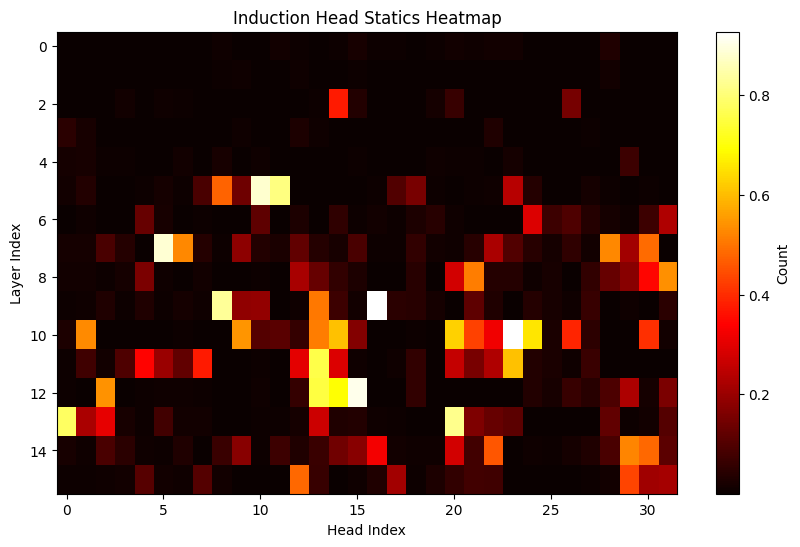

In [160]:
import numpy as np

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(mean_magnitude, aspect='auto', cmap='hot')
plt.colorbar(label='Count')
plt.xlabel('Head Index')
plt.ylabel('Layer Index')
plt.title('Induction Head Statics Heatmap')
plt.show()

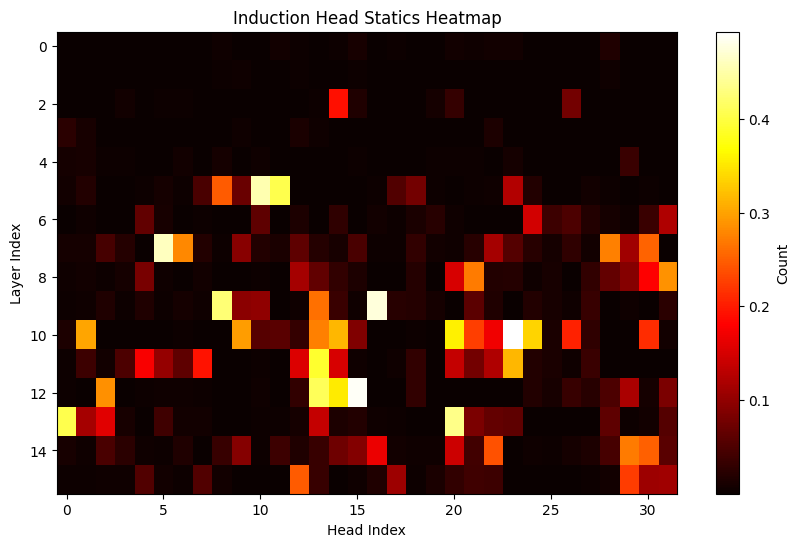

In [161]:
import numpy as np

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(mean_correctness, aspect='auto', cmap='hot')
plt.colorbar(label='Count')
plt.xlabel('Head Index')
plt.ylabel('Layer Index')
plt.title('Induction Head Statics Heatmap')
plt.show()

In [162]:
mean_magnitude[11]

array([4.98171002e-03, 7.37852300e-02, 1.31052994e-02, 9.72341699e-02,
       3.44187001e-01, 2.00146957e-01, 1.20275582e-01, 3.76731552e-01,
       1.08500357e-03, 5.57709239e-04, 6.71721760e-03, 4.50985723e-05,
       3.01916973e-01, 7.60105516e-01, 2.92597553e-01, 1.00995919e-02,
       1.01583258e-03, 9.04792493e-03, 5.67374665e-02, 2.71124739e-03,
       2.60607714e-01, 1.53694337e-01, 2.31598105e-01, 6.08546617e-01,
       3.36969942e-02, 2.26418394e-02, 7.66794211e-03, 6.68271950e-02,
       2.79647718e-04, 1.80711460e-04, 2.57546836e-04, 1.27507111e-04])

In [163]:
mean_magnitude[11][22]

0.23159810471406672

In [164]:
mean_correctness[11]

array([2.53002826e-03, 3.75552510e-02, 6.61566637e-03, 4.91514384e-02,
       1.76721219e-01, 1.02471329e-01, 6.18393148e-02, 1.93140454e-01,
       5.47645426e-04, 2.79849526e-04, 3.44352595e-03, 2.45335998e-05,
       1.55125446e-01, 3.90873172e-01, 1.51467621e-01, 5.27345509e-03,
       5.28300208e-04, 4.74977051e-03, 2.91608040e-02, 1.41677012e-03,
       1.36922470e-01, 7.89152072e-02, 1.22411928e-01, 3.14105649e-01,
       1.73363593e-02, 1.18958647e-02, 3.95551881e-03, 3.52239482e-02,
       1.36976191e-04, 8.93056395e-05, 1.29426533e-04, 6.25230782e-05])

In [165]:
mean_correctness[11][22]

0.1224119276208171

In [166]:
save_dir = "logs/induction_head_statics_new/" + ICL_model_name.replace('/', '_') + ',' + str(k) + ',' + str(dataset_index)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
with open(save_dir + "/head_statics.pickle", 'wb') as f:
    pickle.dump({'mean_magnitude': mean_magnitude, 'mean_correctness': mean_correctness}, f)    

In [167]:
import numpy as np

max_head_per_layer = []
for layer in head_statics:
    max_head_per_layer.append(max(layer))

maxlayer = np.argmax(max_head_per_layer)
# 取最大或最小的4个index

layer_stat = np.array(head_statics[maxlayer])
max_indices = layer_stat.argsort()[-4:][::-1]  # 最大的4个index，降序
min_indices = layer_stat.argsort()[:4]         # 最小的4个index，升序

maxhead = max_indices[1]
minhead = min_indices[1]

NameError: name 'head_statics' is not defined

In [ ]:
min_indices

In [ ]:
ICL_model.config

In [ ]:
example_sample_number = 8

In [ ]:
ICL_model.model.layers[maxlayer].self_attn.o_proj

In [ ]:
ICL_model.model.layers[maxlayer].self_attn.v_proj

In [ ]:
Wo, Wv = get_w_o_and_w_v_from_head(
    ICL_model.model.layers[maxlayer].self_attn.o_proj,
    ICL_model.model.layers[maxlayer].self_attn.v_proj,
    head_index = maxhead,
    dim_per_head = ICL_model.config.head_dim,
    amount_k_head = ICL_model.config.num_key_value_heads
)

import torch

subspace_mapping = torch.matmul(Wo, Wv)

import torch

sample_label_hidden_states = ICL_hidden_states[0][example_sample_number][maxlayer][1:-1:2]
mapped_label = torch.matmul(subspace_mapping.cpu(), sample_label_hidden_states.transpose(1, 0).to(torch.float32)).transpose(1, 0).numpy()

demo_indexs = bench[dataset_index].demonstration_sampler[example_sample_number]
demo_labels = []
for demo_index in demo_indexs:
    demo_labels.append(bench[dataset_index].get_label_space().index(bench[dataset_index].demonstration_set()[demo_index][1]))

from sklearn.decomposition import PCA

# joint_features = np.concatenate([mapped_label, [ICL_hidden_states[0][example_sample_number][maxlayer][-2].numpy()]])

joint_features = mapped_label
pca = PCA(n_components = 2)
pca.fit(joint_features)
pcares = pca.transform(joint_features)[:16]

zero_point = pca.transform([np.zeros_like(mapped_label[0])])

query_point = pca.transform([ICL_hidden_states[0][example_sample_number][maxlayer][-2].numpy()])

print(maxlayer)
print(maxhead)

import pickle
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rc('font',family='Cambria Math')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Cambria Math'] + plt.rcParams['font.serif']

y, x = np.mgrid[slice(-0.2, 0.2 + 0.1, 0.01),
                slice(-0.2, 0.2 + 0.1, 0.01)]

fig, axes=plt.subplots(2,2, figsize=(3.5, 3.5))

figuring_k_numbers = [1, 2, 15, 16]

for i, figuring_k_number in enumerate(figuring_k_numbers):
    den = transfer_to_des(x, y, pcares[:figuring_k_number], demo_labels[:figuring_k_number], zero_point[0])
    max_abs_in_den = np.max(np.abs(den))

    c = axes[i // 2][i % 2].pcolormesh(x, y, den, cmap='RdBu', vmin = -max_abs_in_den, vmax = max_abs_in_den)
    # plt.colorbar(c)

    pcares0 = []
    pcares1 = []
    for j, label in enumerate(demo_labels[:figuring_k_number]):
        if label == 0:
            pcares0.append(pcares[j])
        else:
            pcares1.append(pcares[j])
    pcares0 = np.array(pcares0)
    pcares1 = np.array(pcares1)
    
    if len(pcares0) > 0:
        axes[i // 2][i % 2].scatter(pcares0.T[0], pcares0.T[1], c = "black", marker = "x", label = "Positive Label Tokens")
    if len(pcares1) > 0:
        axes[i // 2][i % 2].scatter(pcares1.T[0], pcares1.T[1], c='none',marker='o', edgecolors='black', label = "Positive Label Tokens")
    axes[i // 2][i % 2].scatter(zero_point[0][0], zero_point[0][1], color = 'black', marker='^', label = "Zero Point")
    axes[i // 2][i % 2].set_title("k = " + str(figuring_k_number), fontsize=10)
    axes[i // 2][i % 2].set_xticks([])
    axes[i // 2][i % 2].set_yticks([])
    
fig.suptitle("Layer " + str(maxlayer) +  ", Head " + str(maxhead) + ", Correct Rate: 0.00", fontsize=10)
# fig.suptitle("Layer " + str(maxlayer) +  ", Head " + str(maxhead) + ", Correct Rate: 0.95", fontsize=10)
    
# from matplotlib.backends.backend_pdf import PdfPages

# pdf = PdfPages('Exp4_4_' + ICL_model_name.replace('/', '_') + str(maxlayer) + str(maxhead) + str(dataset_index) + str(example_sample_number) + '.pdf')
# pdf.savefig(bbox_inches='tight', pad_inches = 0.01)
# pdf.close()

In [ ]:
Wo, Wv = get_w_o_and_w_v_from_head(
    ICL_model.model.layers[maxlayer].self_attn.o_proj,
    ICL_model.model.layers[maxlayer].self_attn.v_proj,
    head_index = minhead,
    dim_per_head = ICL_model.config.head_dim,
    amount_k_head = ICL_model.config.num_key_value_heads
)

import torch

subspace_mapping = torch.matmul(Wo, Wv)

import torch

sample_label_hidden_states = ICL_hidden_states[0][example_sample_number][maxlayer][1:-1:2]
mapped_label = torch.matmul(subspace_mapping.cpu(), sample_label_hidden_states.transpose(1, 0).to(torch.float32)).transpose(1, 0).numpy()

demo_indexs = bench[dataset_index].demonstration_sampler[example_sample_number]
demo_labels = []
for demo_index in demo_indexs:
    demo_labels.append(bench[dataset_index].get_label_space().index(bench[dataset_index].demonstration_set()[demo_index][1]))

from sklearn.decomposition import PCA

# joint_features = np.concatenate([mapped_label, [ICL_hidden_states[0][example_sample_number][maxlayer][-2].numpy()]])

joint_features = mapped_label
pca = PCA(n_components = 2)
pca.fit(joint_features)
pcares = pca.transform(joint_features)[:16]

zero_point = pca.transform([np.zeros_like(mapped_label[0])])

query_point = pca.transform([ICL_hidden_states[0][example_sample_number][maxlayer][-2].numpy()])

print(maxlayer)
print(minhead)

import pickle
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rc('font',family='Cambria Math')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Cambria Math'] + plt.rcParams['font.serif']

y, x = np.mgrid[slice(-0.35, 0.35 + 0.1, 0.01),
                slice(-0.35, 0.35 + 0.1, 0.01)]

fig, axes=plt.subplots(2,2, figsize=(3.5, 3.5))

figuring_k_numbers = [1, 2, 15, 16]

for i, figuring_k_number in enumerate(figuring_k_numbers):
    den = transfer_to_des(x, y, pcares[:figuring_k_number], demo_labels[:figuring_k_number], zero_point[0])
    max_abs_in_den = np.max(np.abs(den))

    c = axes[i // 2][i % 2].pcolormesh(x, y, den, cmap='RdBu', vmin = -max_abs_in_den, vmax = max_abs_in_den)
    # plt.colorbar(c)

    pcares0 = []
    pcares1 = []
    for j, label in enumerate(demo_labels[:figuring_k_number]):
        if label == 0:
            pcares0.append(pcares[j])
        else:
            pcares1.append(pcares[j])
    pcares0 = np.array(pcares0)
    pcares1 = np.array(pcares1)
    
    if len(pcares0) > 0:
        axes[i // 2][i % 2].scatter(pcares0.T[0], pcares0.T[1], c = "black", marker = "x", label = "Positive Label Tokens")
    if len(pcares1) > 0:
        axes[i // 2][i % 2].scatter(pcares1.T[0], pcares1.T[1], c='none',marker='o', edgecolors='black', label = "Positive Label Tokens")
    axes[i // 2][i % 2].scatter(zero_point[0][0], zero_point[0][1], color = 'black', marker='^', label = "Zero Point")
    axes[i // 2][i % 2].set_title("k = " + str(figuring_k_number), fontsize=10)
    axes[i // 2][i % 2].set_xticks([])
    axes[i // 2][i % 2].set_yticks([])
    
fig.suptitle("Layer " + str(maxlayer) +  ", Head " + str(maxhead) + ", Correct Rate: 0.00", fontsize=10)
# fig.suptitle("Layer " + str(maxlayer) +  ", Head " + str(maxhead) + ", Correct Rate: 0.95", fontsize=10)
    
# from matplotlib.backends.backend_pdf import PdfPages

# pdf = PdfPages('Exp4_4_' + ICL_model_name.replace('/', '_') + str(maxlayer) + str(maxhead) + str(dataset_index) + str(example_sample_number) + '.pdf')
# pdf.savefig(bbox_inches='tight', pad_inches = 0.01)
# pdf.close()